In [1]:
import numpy as np
import matplotlib.pyplot as pl

In [2]:
def Ode (x, y):
    return x - y

In [3]:
def Solution (c, x):
    return c / np.exp (x) + x - 1

In [4]:
def Constant (x0, y0):
    return (y0 - x0 + 1) * np.exp (x0)

In [5]:
Xmin = 0; Xmax = 5
Ymin = 1; Ymax = 4

X0 = 0
Y0 = 2
C = Constant (X0, Y0)

H = 0.2

In [6]:
def SlopeField (ode, xmin, xmax, ymin, ymax, h):
    dx = xmax - xmin; m = int (dx / h + 0.5); x = np.linspace (xmin, xmax, m + 1); dx /= m
    dy = ymax - ymin; n = int (dy / h + 0.5); y = np.linspace (ymin, ymax, n + 1); dy /= n
    
    xx, yy = np.meshgrid (x, y)
    mm = ode (xx, yy); uu = 0.9 * h / np.sqrt (1 + mm ** 2); vv = mm * uu
    
    pl.axis ('equal')
    pl.plot (xx, yy, '.', color = 'gray')
    pl.quiver (xx - uu / 2, yy - vv / 2, uu, vv, angles = 'xy', scale_units = 'xy', scale = 1, width = 0.001)

In [7]:
def SolveIVP (ode, x0, y0, h, xmax):
    n = int ((xmax - x0) / h + 0.5)
    xx = np.zeros (n + 1); xx [0] = x0
    yy = np.zeros (n + 1); yy [0] = y0
    for i in range (n):
        xx [i + 1] = xx [i] + h
        yy [i + 1] = yy [i] + h * ode (xx [i], yy [i])
    return [xx, yy]

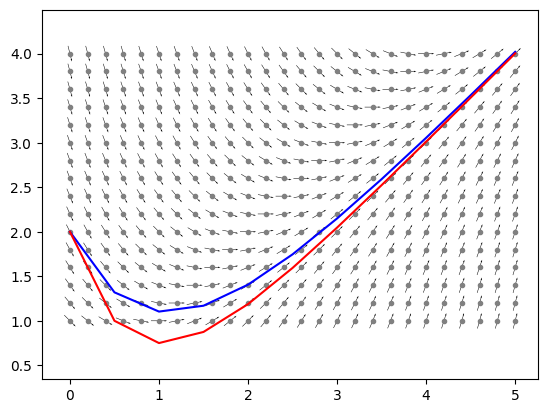

In [8]:
SlopeField (Ode, Xmin, Xmax, Ymin, Ymax, H)
[xx, yy] = SolveIVP (Ode, X0, Y0, 0.5, Xmax)
pl.plot (xx, Solution (C, xx), 'blue')
pl.plot (xx, yy, 'red')

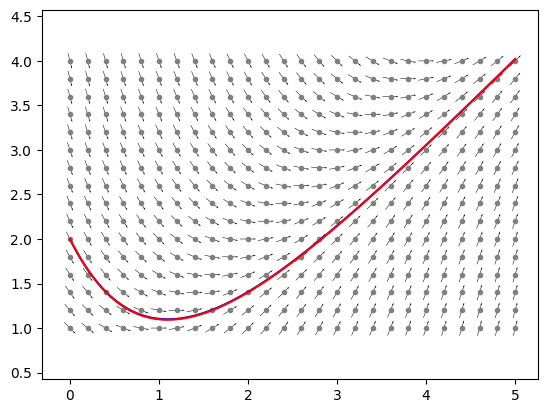

In [9]:
SlopeField (Ode, Xmin, Xmax, Ymin, Ymax, H)
[xx, yy] = SolveIVP (Ode, X0, Y0, 0.01, Xmax)
pl.plot (xx, Solution (C, xx), 'blue')
pl.plot (xx, yy, 'red')

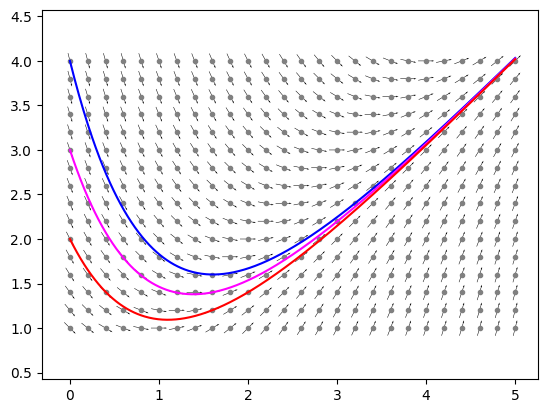

In [10]:
SlopeField (Ode, Xmin, Xmax, Ymin, Ymax, H)
[xx, yy] = SolveIVP (Ode, X0, 4, 0.01, Xmax); pl.plot (xx, yy, 'blue')
[xx, yy] = SolveIVP (Ode, X0, 3, 0.01, Xmax); pl.plot (xx, yy, 'magenta')
[xx, yy] = SolveIVP (Ode, X0, 2, 0.01, Xmax); pl.plot (xx, yy, 'red')